# Modelling

This document follows the data cleaning and scraping by modelling the footfall data. The model is selected, tuned and fitted using the footfall data between 2019 and 2024. The model is then used later on to predict the 2025 footfall, to allow event evaluation.

The below steps are followed:

### 1) Model selection

The performance of four different machine learning models is tested using 10-fold cross validation. The models include:

* Linear regression
* Random Forest
* XGBoost
* Extra Trees Regressor

The outputs of the 10-fold cross validation process are used to calculate the error metric scores associated with that model (averaged over all folds). The MAE, the MAPE, the R2 and the RMSE metrics are compared to find the model that will best fit the data.

**Conclusion:** Random Forest Regression is the best performing model. After going through model selection **and** conducting model evaluation.

### 2) Model Evaluation

The performance of the model is tested, using a 80-20 test split with the chronological order of the data preserved. The model performance is evaluated using the error metrics of MAE, MAPE, R2 and RMSE.

### 3) Hyperparameter Tuning


Hyperparameter tuning is performed as it allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. 

### 4) Fitting the Final Model

Using the optimal hyperparameters found during the tuning, the model is fitted again, this time using the whole dataset (no training and test splits).

### 5) Feature Importance

The feature importance of the model predictor variables is investigated.

### 6) Using Model to Evaluate Events

The final model is used to quantify the change in footfall that would otherwise been predicted in 2025.

In [1]:
pip install matplotlib geopandas numpy scikit-learn

  Using cached numpy-2.4.0-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

Here the data used to train and evaluate the models only contains the footfall data from 2019 to 2024.

In [3]:
#Load training footfall (2019-2024) data
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - Bradford District MetOffice\Bradford Analysis- RFR No lag-roll\footfall_cleaned_19_24")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2188 non-null   int64  
 1   datestamp                          2188 non-null   object 
 2   estimated_actual_footfall          2188 non-null   float64
 3   estimated_actual_footfall_rolling  2188 non-null   int64  
 4   year                               2188 non-null   int64  
 5   month                              2188 non-null   int64  
 6   monthday                           2188 non-null   int64  
 7   weekday                            2188 non-null   int64  
 8   week_of_year                       2188 non-null   int64  
 9   Sin_weekday                        2188 non-null   float64
 10  Cos_weekday                        2188 non-null   float64
 11  Sin_monthday                       2188 non-null   float

In [4]:
data.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.5,0.866025,0,1,1,0,6.158333,0.0,24.490587,27067.838
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.5,0.866025,0,0,1,0,2.304167,0.0,10.086427,27147.844
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.5,0.866025,0,0,1,0,0.387500,0.0,6.479999,27235.123
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.5,0.866025,0,0,1,0,2.064583,0.0,15.629971,27329.416
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.5,0.866025,1,0,0,0,3.768750,0.0,14.168641,27430.486


In [5]:
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'weekday', 'week_of_year', 'monthday', 'datestamp', 'estimated_actual_footfall_rolling'], axis=1, inplace=True)
data.head()

,estimated_actual_footfall,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,530996.0,2019,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,1,1,0,6.158333,0.0,24.490587,27067.838
1,568621.0,2019,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,0,1,0,2.304167,0.0,10.086427,27147.844
2,606939.0,2019,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,0,0,1,0,0.387500,0.0,6.479999,27235.123
3,508695.0,2019,-8.660254e-01,-0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,0,0,1,0,2.064583,0.0,15.629971,27329.416
4,468546.0,2019,-8.660254e-01,0.5,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,1,0,0,0,3.768750,0.0,14.168641,27430.486


In [6]:
#Chek NAs and drop rows with no footfall information
data['estimated_actual_footfall'].isna().sum()
data = data.dropna(subset=['estimated_actual_footfall'])
data['estimated_actual_footfall'].isna().sum()

0

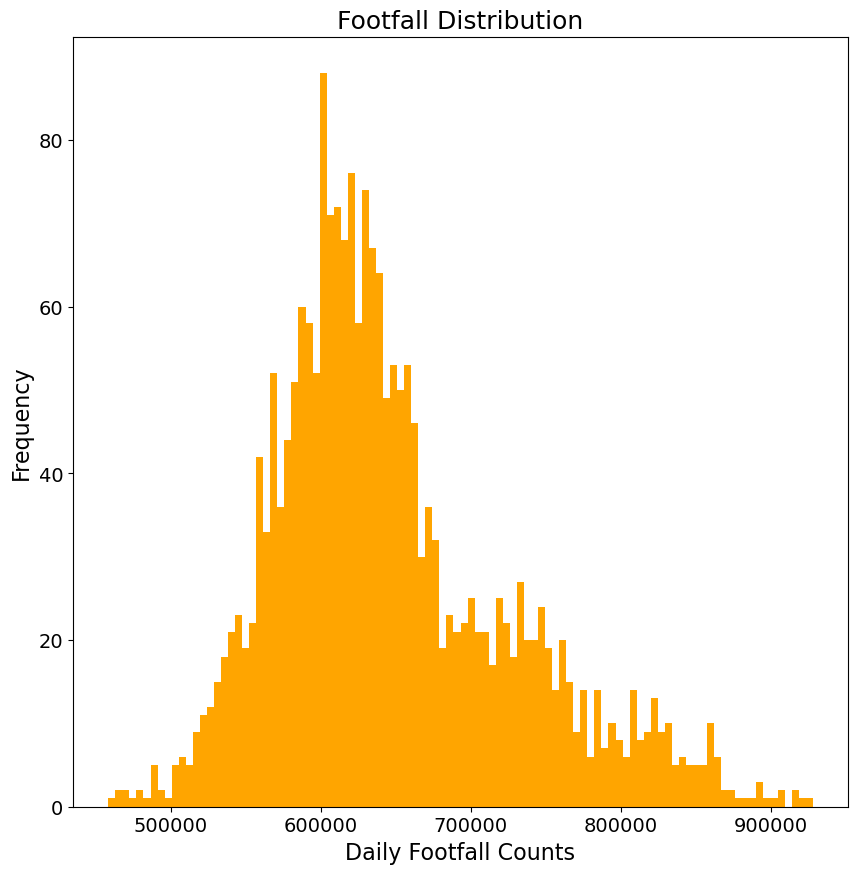

In [7]:
#Plot distribution of footfall counts
plt.figure(figsize=(10, 10))
plt.hist(data.estimated_actual_footfall, bins=100, color='orange')
plt.title('Footfall Distribution', fontsize=18)
plt.xlabel('Daily Footfall Counts', fontsize= 16)
plt.ylabel('Frequency', fontsize=16)
plt.tick_params(axis='both', labelsize= 14)
ax = plt.gca()  #get axes
ax.xaxis.get_offset_text().set_fontsize(14)
plt.show()

Explore relationship between variables.

In [8]:
#Scatter plots of relationship 
# between dependent variable (footfall counts) and contextual variables -> change x to investigate different predictor variables
#plt.figure(figsize=(10, 10))

#x = data['precipitation_sum'] # <- Change to different variables
#y = data['estimated_actual_footfall_rolling']

#Calculate fitted line
#z = np.polyfit(x, y, 1)
#trend = np.poly1d(z)

#Predicted y values
#y_pred = trend(x)

#Calculate R-Squared
#r = np.corrcoef(y,y_pred)[0,1]
#r2 = r**2

#Add percentage mean bias
#mean_bias = np.mean(y_pred - y)
#pmb = (mean_bias / np.mean(y)) * 100

#Plot points
#plt.scatter(x=x, y=y, color='blue', s=50, alpha=0.6)
#plt.xlabel("Precipitation", fontsize=20, weight='bold')
#plt.ylabel("Daily Footfall Counts", fontsize=20, weight='bold')

#Plot trend line and legend
#plt.plot(np.sort(x), trend(np.sort(x)), linewidth=3, color='red', linestyle='--', label=f'Trend: y = {z[0]:.3f}x + {z[1]:.3f} \n$R^2$ = {r2:.3f} \nPMB = {pmb:.3f}%')
#plt.legend(fontsize=18)

#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
#Make the 1e-9 bigger at top of Y axis
#ax = plt.gca()  #get axes
#ax.yaxis.get_offset_text().set_fontsize(14)

#plt.title("")
#plt.show()

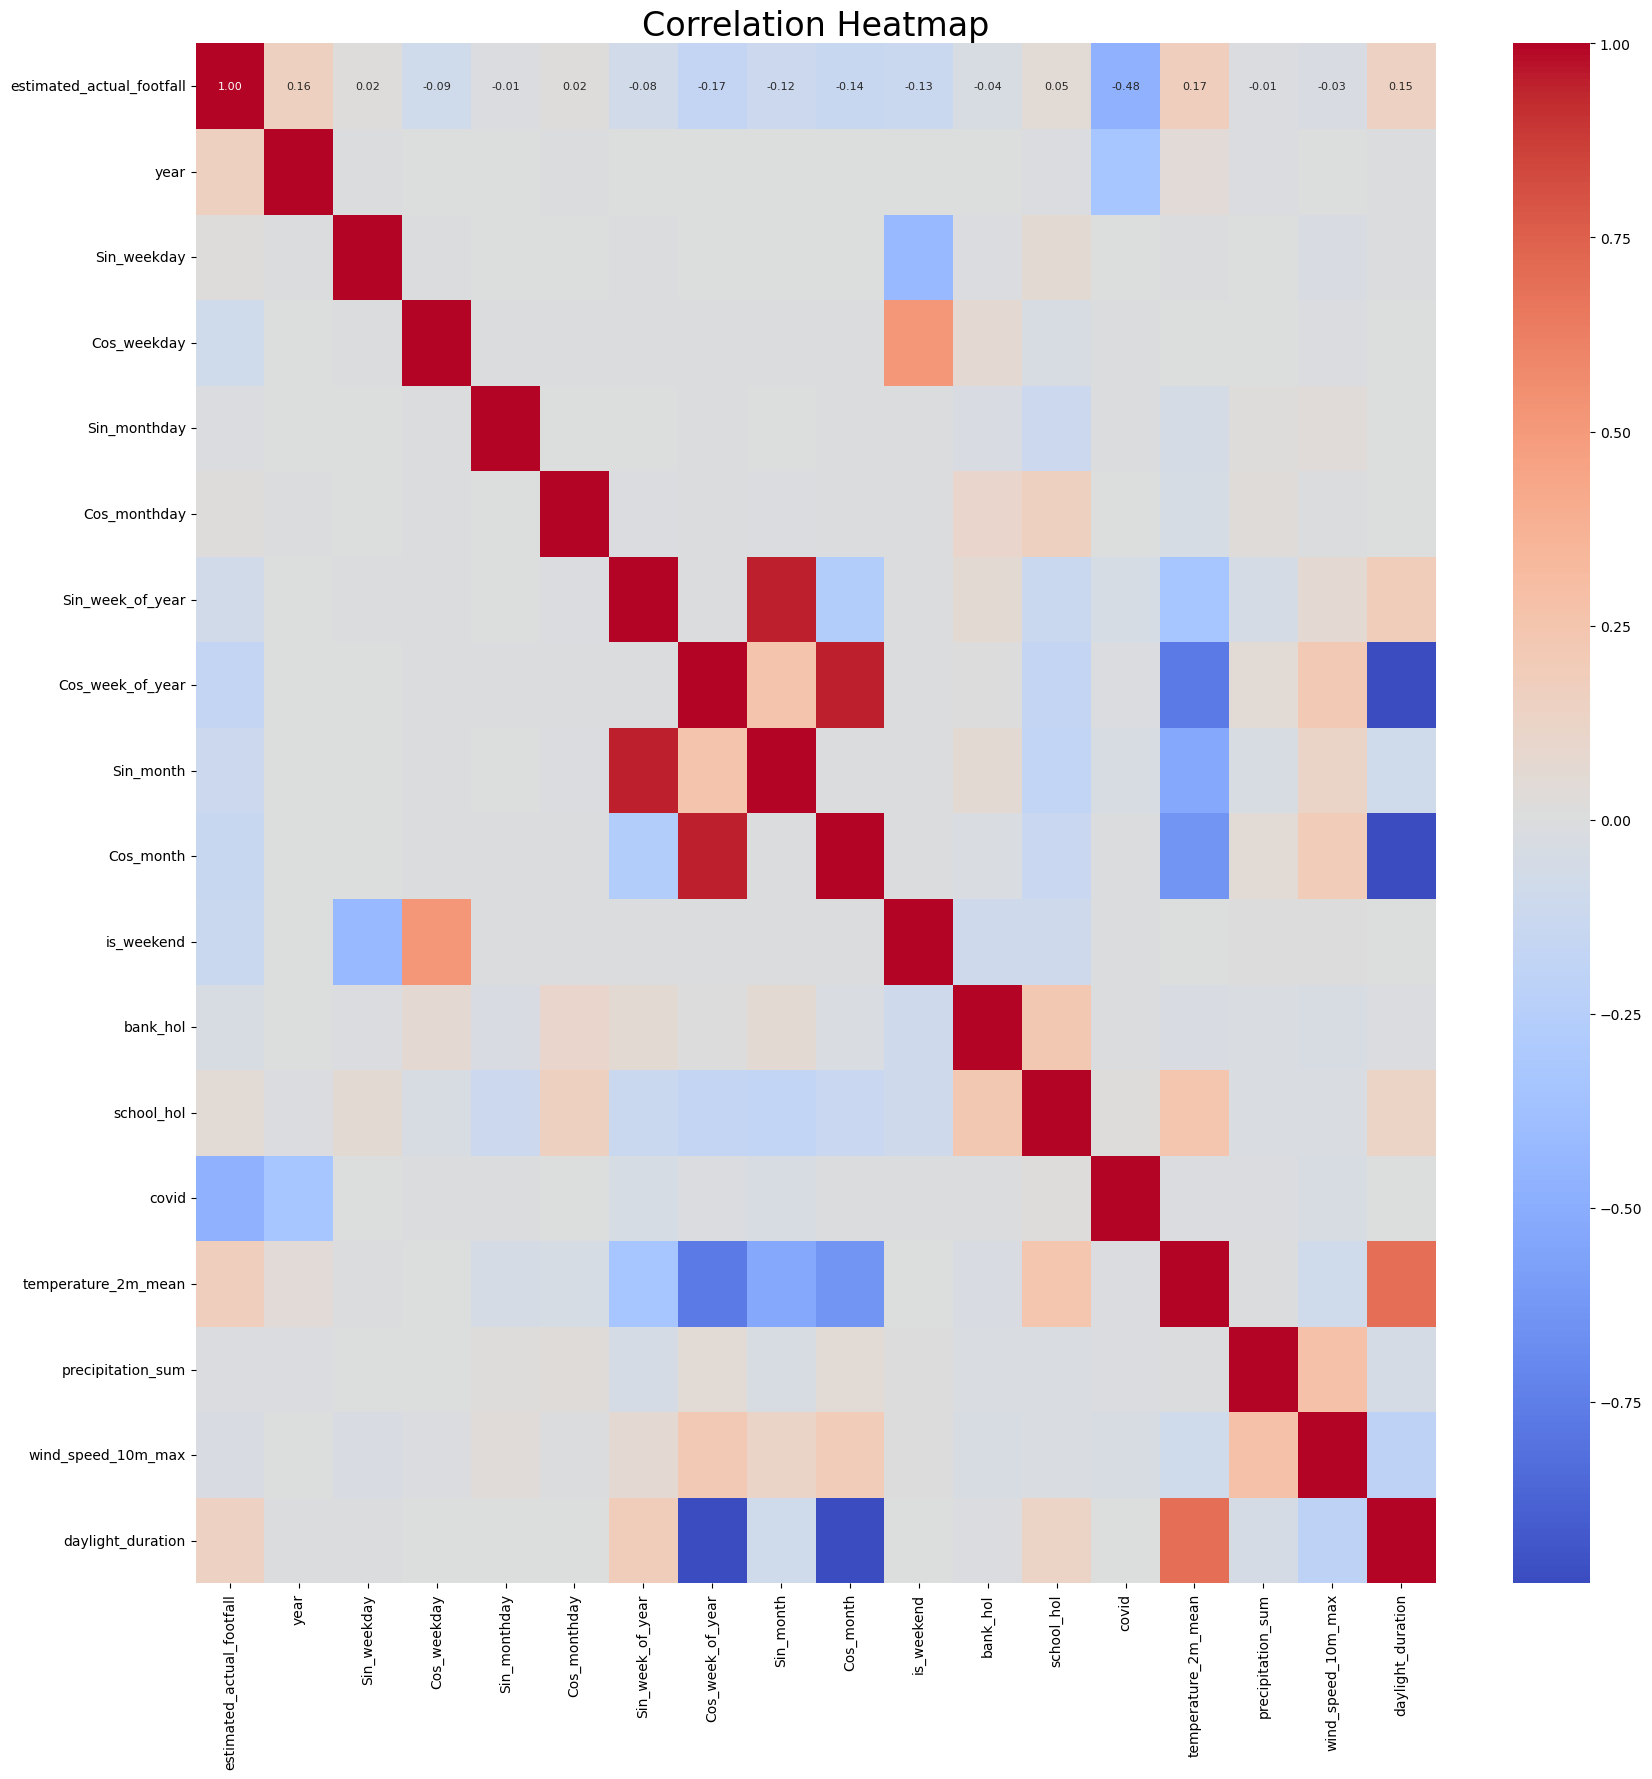

In [9]:
#Correlation Heatmap
plt.figure(figsize=(20, 20))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.title('Correlation Heatmap', fontsize=24)
plt.show()

# 1- Model Selection

In [10]:
!pip install xgboost
!pip install scikit-learn==1.4.2

  Using cached scikit_learn-1.4.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp311-cp311-win_amd64.whl (10.6 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
eli5 0.16.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.4.2 which is incompatible.


In [11]:
#Load packages
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate
from time import time

In [12]:
#Prepare data for modelling

def prepare_x_y_data(input_data):
    data = input_data.copy()
    # Fill any missing values
    data = data.fillna(0)
    
    # Add a random variables (to compare performance of other variables against)
    #rng = np.random.RandomState(seed=42)
    #data['random'] = np.random.random(size=len(data)) #continuous random variable between 0 and 1
    #data["random_cat"] = rng.randint(3, size=data.shape[0]) #categorical random variable, integer is either 0, 1 or 2

    # Prepare data for modelling 
    # Split into predictor/predictand variables
    Xfull = data.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
    Yfull = data['estimated_actual_footfall'].values #target variable

    return Xfull, Yfull

# Run function
Xfull, Yfull = prepare_x_y_data(data)

In [13]:
print("Running models with explanatory variables: ", Xfull.columns)

Running models with explanatory variables:  Index(['year', 'Sin_weekday', 'Cos_weekday', 'Sin_monthday', 'Cos_monthday',
       'Sin_week_of_year', 'Cos_week_of_year', 'Sin_month', 'Cos_month',
       'is_weekend', 'bank_hol', 'school_hol', 'covid', 'temperature_2m_mean',
       'precipitation_sum', 'wind_speed_10m_max', 'daylight_duration'],
      dtype='object')


Run the 4 models with cross-validation

Define the error metrics for the cross-validation to return, and the parameters of the cross validation


In [14]:
#Define error metrics
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']
#Split the data into 10 folds, shuffle=True ensures randomization
cv_parameters = KFold(n_splits=10, random_state=1, shuffle=True)

In [15]:
# Create dataframe to store the scores for all the models
error_metric_scores = pd.DataFrame()

In [16]:
#Create the 4 models
lr_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['linear_regressor',LinearRegression()]])
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
xgb_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['xgb_regressor',xgb.XGBRegressor(random_state=1, n_jobs = 16)]])
et_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['et_regressor',ExtraTreesRegressor (random_state = 1, n_jobs = 16)]])

#Create dictionary to contain model results
models_dict = {"linear_regressor": lr_model_pipeline, 
               "xgb_regressor":xgb_model_pipeline,
               "rf_regressor":rf_model_pipeline,
               "et_regressor": et_model_pipeline}

In [17]:
# Run models with 10 fold cross validation

for model_name, model_pipeline in models_dict.items():
    print(model_name)
    # Use cross_validate to return the error scores associated with this model and this data
    start = time()
    model_output = cross_validate(model_pipeline, Xfull, Yfull, cv=cv_parameters, scoring=error_metrics, error_score="raise")

    end = time()
    print('Ran in {} minutes'.format(round((end - start)/60),2)) #how long model took to run
    
    # Formulate the different error scores into a dataframe
    error_metrics_df =pd.DataFrame({'mae': round(abs(model_output['test_neg_mean_absolute_error'].mean()),2), 
                  'mape': round(abs(model_output['test_neg_mean_absolute_percentage_error'].mean()),2),
                  'r2': round(abs(model_output['test_r2'].mean()),2), 
                  'rmse': round(abs(model_output['test_neg_root_mean_squared_error'].mean()),2)},
                 index =[model_name])
        
    # Add evaluation metric scores for this model to the dataframe containing the metrics for each model
    error_metric_scores = pd.concat([error_metric_scores, error_metrics_df])

linear_regressor
Ran in 0 minutes
xgb_regressor
Ran in 0 minutes
rf_regressor
Ran in 0 minutes
et_regressor
Ran in 0 minutes


In [18]:
#Check results
error_metric_scores.head()

,mae,mape,r2,rmse
linear_regressor,51195.70,0.08,0.28,67426.43
xgb_regressor,27181.70,0.04,0.78,37408.32
rf_regressor,25116.35,0.04,0.81,34452.05
et_regressor,24861.09,0.04,0.81,34208.01


**Results**:
* Mean Absolute Error: Extra Trees Regressor has the best accuracy (lowest mae)
* Mean Absolute Percentage Error: several models have the best accuracy (lowest mape)
* R-Squared: Extra Trees Regressor has the best accuracy (highest r2)
* Root Mean Squared Error: Extra Trees Regressor has the best accuracy (lowest rmse)

Conclusion: Extra Trees Regressor is the best performing model.

However, when running the below model evaluation, with 80/20 split of data by chronological order and TimeSeriesSplit in tuning, **the Random Forest Regressor outperforms the Extra Trees Regressor. Thus, Random Forest Regressor is chosen.**

# 2- Evaluating the Random Forest Regression model

The first 80% of the data is used for training, and the last 20% for testing. Potential issues: the final portion of time might exhibit different patterns to the rest of the time.

As we are analysing time series data, we cannot choose random samples and assign them to either the test set or the train set because it doesn't make sense to use values from the future to forecast the past. There is a temporal dependency between observations, and this must be preserved during testing.

So, need to ensure that the test set always has a later time stamp than the training set.

In [19]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error

In [20]:
# Custom function for neg_mean_absolute_percentage_error
def neg_mean_absolute_percentage_error(y_true, y_pred):
    return -100 * np.mean(np.abs((y_true - y_pred) / y_true))

In [21]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [22]:
# Set up model pipeline
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
model_dict = {"rf_regressor":rf_model_pipeline}

Get testing and training data

In [23]:
Xfull, Yfull = prepare_x_y_data(data)
dates = pd.read_csv(r"c:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - Bradford District MetOffice\Bradford Analysis- RFR No lag-roll\footfall_cleaned_19_24")['datestamp']

In [24]:
# Create train/test index lists based on a 80/20 split of data by chronological order
train_index = Xfull[0:int(len(Xfull)*0.8)].index.tolist()
test_index = Xfull[int(len(Xfull)*0.8):].index.tolist()

In [25]:
# Lists to store the error metric scores
mae_scores = []
rmse_scores= []
r2_scores= []
neg_mae_scores = []
# Lists to store predicted and actual values
predicted_values=[]
observed_values = []
# List to store the dates
dates_used = []

In [26]:
start = time()

# Get train and testing data for this fold
print(f"train index: {len(train_index)}")
print(f"test index: {len(test_index)}")
print(f"percentage of data used as testing: {round(len(test_index)/len(train_index)*100,1)}")

X_train, X_test = Xfull.iloc[train_index], Xfull.iloc[test_index]
y_train, y_test = Yfull[train_index], Yfull[test_index]

# Fit the model on the training data
rf_model_pipeline.fit(X_train, y_train)
# Use it to make predictions on the testing data, and store these
y_pred = rf_model_pipeline.predict(X_test)
predicted_values.append(y_pred)
# Store the datetimes
dates_used.append(dates[train_index])
# Store the actual values for the testing data
observed_values.append(y_test)
# Calculate the error metrics for this fold and append to the scores lists
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
rmse_scores.append(root_mean_squared_error(y_test, y_pred))
neg_mae_scores = [-score for score in mae_scores]        

end = time()
#Get time it took to run model in full
print('Ran cross_val_predict in {} minutes'.format(round((end - start)/60),2))

train index: 1750
test index: 438
percentage of data used as testing: 25.0
Ran cross_val_predict in 0 minutes


In [27]:
# Store lists of predicted and observed values
predicted_values_all = []
observed_values_all= []
for i in range(len(predicted_values)):
    for j in range(len(predicted_values[i])):
        observed_values_all.append(observed_values[i][j])
        predicted_values_all.append(predicted_values[i][j])

In [28]:
# Print evaluation metrics
print(f"Mean absolute error: {mae_scores}")
print(f"Mean R2: {r2_scores}")
print(f"Mean RMSE: {rmse_scores}")

Mean absolute error: [127526.82716894976]
Mean R2: [-7.2061086234952185]
Mean RMSE: [141112.34508036438]


**Results:**

There is a need to tune the model's hyperparameters to improve the scores.

# 3- Hyperparameters Tuning with RandomizedSearchCV
Hyperparameter tuning allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. The Randomized Search exhaustively searches through all possible combinations of parameters provided in the param_grid.

The TimeSeriesSplit allows cross-validation for time series data, as future data should not be used to predict past data and random splits can cause data leakage. TimeSeriesSplit ensures that the training set comes before the test set.

As the model fitting is manually done here, the X values need to be scaled manually, whereas they were previously within the model pipeline.

In [29]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [30]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state= 1))])

In [31]:
#Create HyperParameter grid
param_grid = {
    'rf__n_estimators': [50, 100, 150, 200, 250, 300], #number of trees
    'rf__max_depth': [10, 20, 30, 40, None], #maximum depth of each tree
    'rf__min_samples_split': [2, 5, 10], #minimum n° of samples required to split a node
    'rf__min_samples_leaf': [1, 2, 4], #minimum samples at leaf node
    'rf__max_features': ['sqrt', 'log2', None], #n° of features to consider per split
    'rf__bootstrap': [True, False]
}

In [32]:
#Find the best hyperparameters settings for this model
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

#TimeSeriesSplit CV
tscv= TimeSeriesSplit(n_splits= 10)

rfr_Rsearch = RandomizedSearchCV(estimator= rf_model, 
                            param_distributions=param_grid, 
                            cv= tscv, 
                            verbose=2, 
                            n_iter=100, 
                            random_state=1,
                            n_jobs= 1,
                            scoring= 'neg_mean_absolute_error',
                            return_train_score= True
                            )
rfr_Rsearch.fit(X_train, y_train)

#Display best hyperparameters
print('Best hyperparameters:', rfr_Rsearch.best_params_)
print('Best score', -rfr_Rsearch.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=250; total time=   0.1s
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=250; total time=   0.1s
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=250; total time=   0.1s
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=250; total time=   0.2s
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=250; total time=   0.2s
[CV] END rf__bootstrap=False, rf__max_depth=30, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_esti

In [33]:
#Evaluate the holdout test set
#Make predictions
y_pred = rfr_Rsearch.best_estimator_.predict(X_test)

#Use predictions to evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Print evaluation metrics
print(f"Mean absolute error: {mae}")
print(f"Mean R2: {r2}")
print(f"Mean RMSE: {rmse}")

Mean absolute error: 121563.95179347113
Mean R2: -6.31643975226428
Mean RMSE: 133243.57573212564


## Plot predicted vs actual values

In [34]:
pip install datashader

Note: you may need to restart the kernel to use updated packages.


In [35]:
import datashader as ds
from datashader.mpl_ext import dsshow

# Code from: https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density-in-matplotlib/53865762#53865762
def using_datashader(ax, x, y, normalisation):
    df = pd.DataFrame(dict(x=x, y=y))
    dsartist = dsshow(df,ds.Point("x", "y"),ds.count(), vmin=0.1, vmax=100,norm=normalisation,aspect="auto",ax=ax)
    cbar = plt.colorbar(dsartist, ax=ax)
    cbar.ax.tick_params(labelsize=10) 

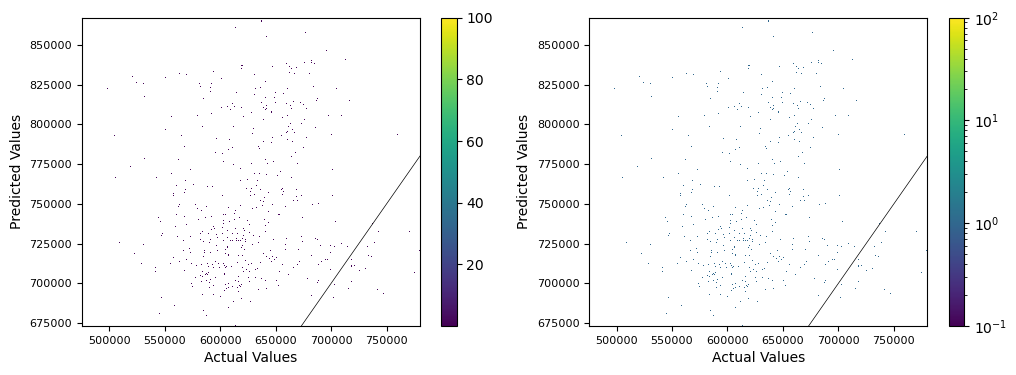

In [36]:
#Plot log and linear scales

import datashader as ds
from datashader.mpl_ext import dsshow
fig, axs = plt.subplots(ncols=2, figsize = (12,4))

# Plot with linear scale
using_datashader(axs[0], y_test, predicted_values_all, 'linear')
axs[0].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[0].set_ylabel("Predicted Values", size=10)
axs[0].set_xlabel("Actual Values", size=10)
# axs[0].set_xlim([0, 2000])
# axs[0].set_ylim([0, 2000])
axs[0].tick_params(axis='both', which='major', labelsize=8)

# Plot with log scale
using_datashader(axs[1], y_test, predicted_values_all, 'log')
axs[1].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[1].set_ylabel("Predicted Values", size=10)
axs[1].set_xlabel("Actual Values", size=10)
# axs[1].set_xlim([0, 2000])
# axs[1].set_ylim([0, 2000]);
axs[1].tick_params(axis='both', which='major', labelsize=8)

# 4- Fitting Final RFR Model

In [37]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

The final model is fitted, using all of the data (no train or test sets) and the optimal hyperparameters found with tuning.

In [38]:
# Fit the final model
rfr_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 50,
                                  max_depth= 30,
                                  min_samples_split= 10,
                                  min_samples_leaf = 4,
                                  max_features= 'sqrt',
                                  random_state= 1,
                                  bootstrap= True))])

#Run the Random Forest Regressor, with the whole dataset
rfr_pipeline_final.fit(Xfull, Yfull)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=30, max_features='sqrt',
                                       min_samples_leaf=4, min_samples_split=10,
                                       n_estimators=50, random_state=1))])

# 5- RFR Model Feature Importance

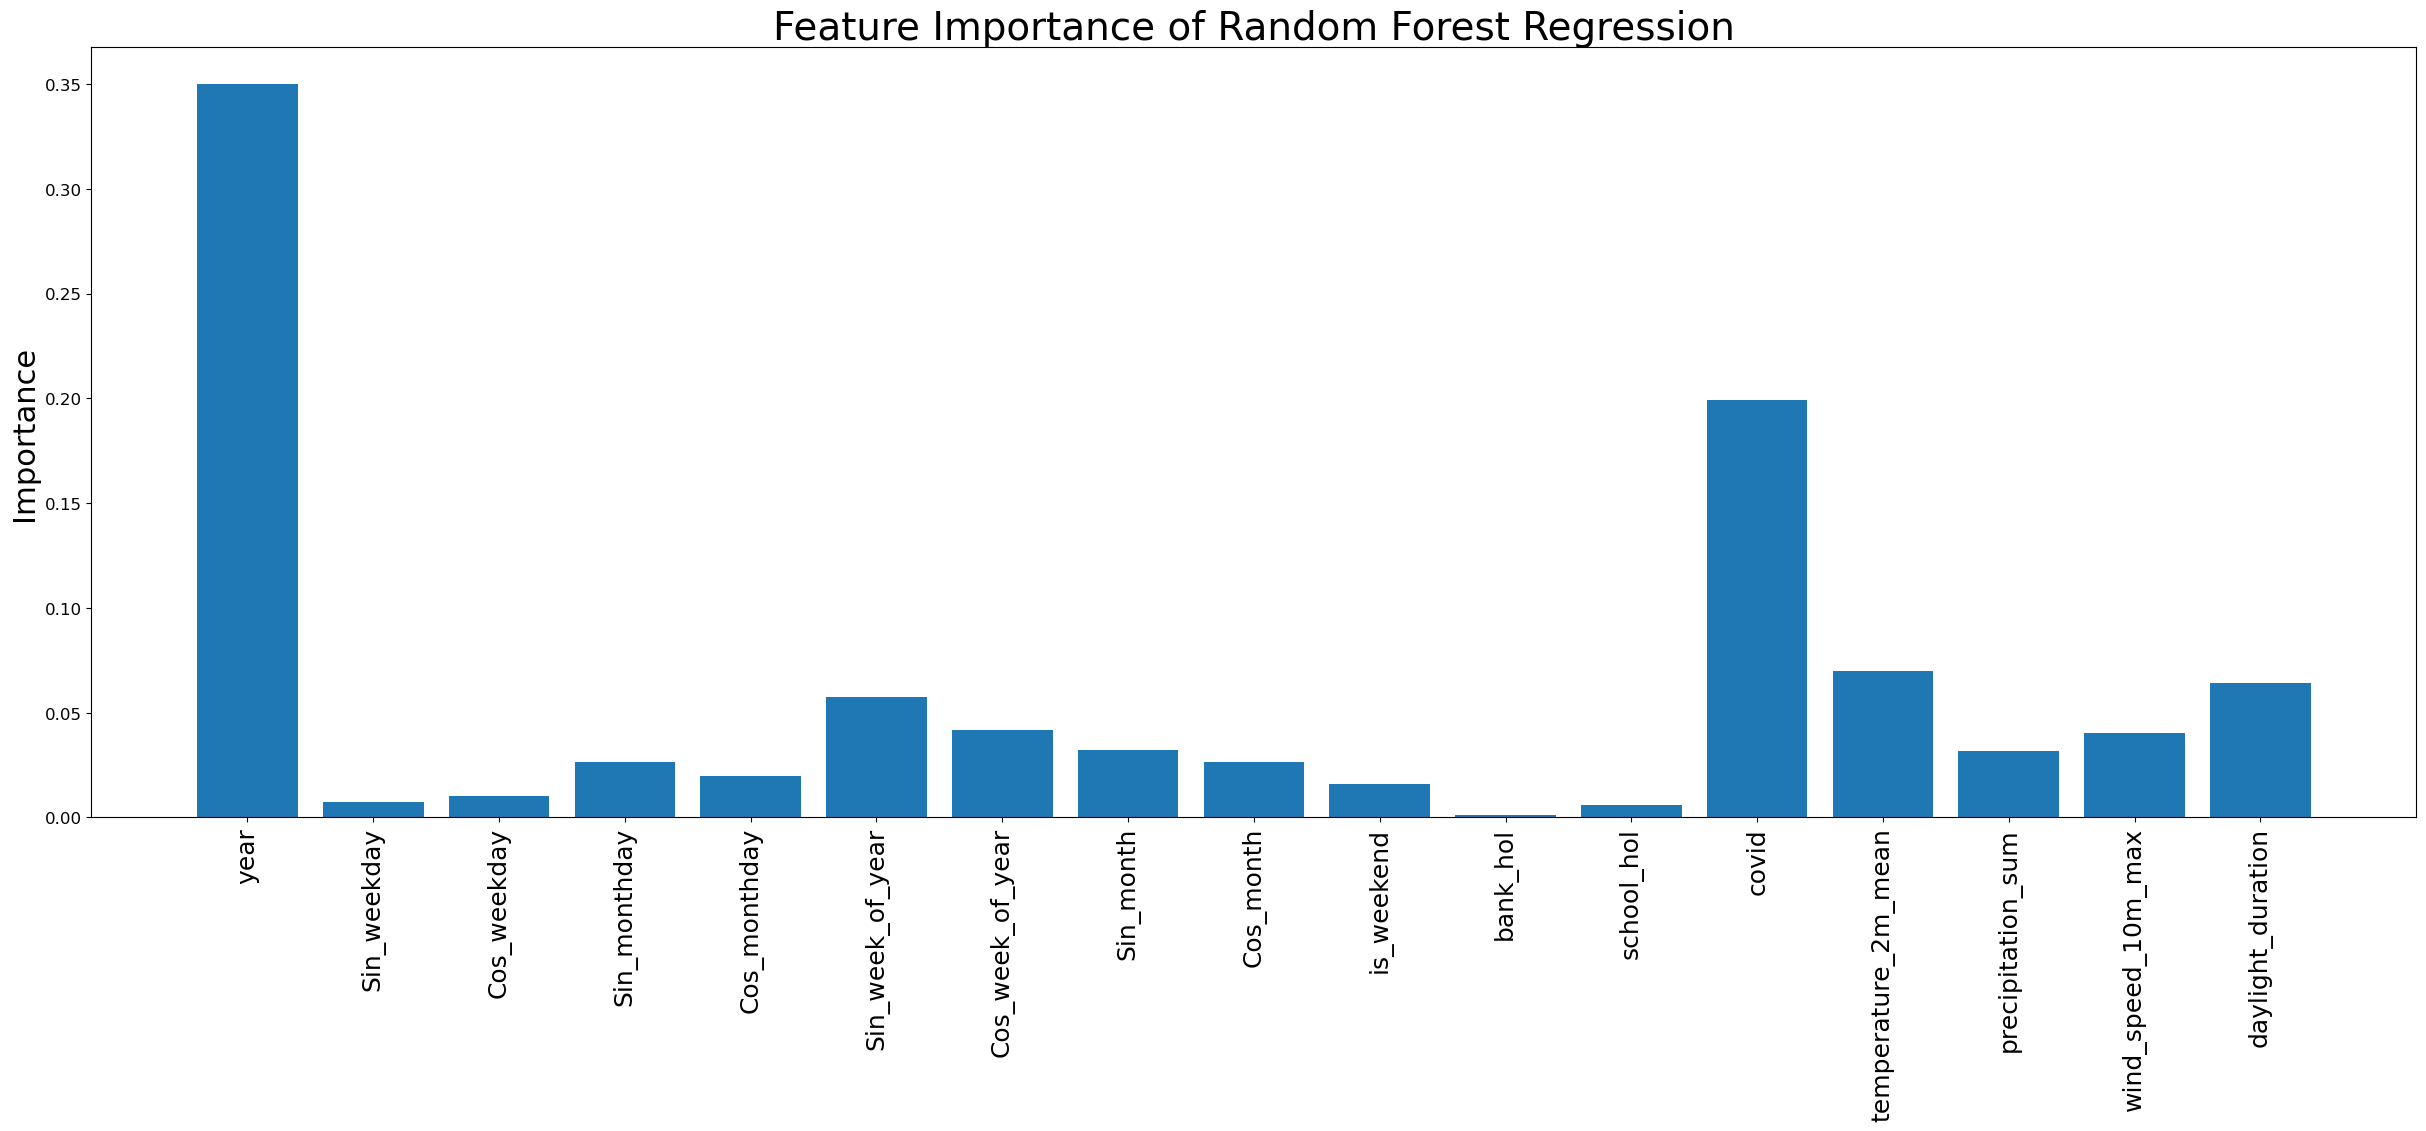

In [39]:
#Extract the rfr model from inside the pipeline
rf_model_final = rfr_pipeline_final.named_steps['rf']
#Extract feature importance from model
importance = rf_model_final.feature_importances_
#Extract feature names
features = Xfull.columns.tolist()

#Plot
plt.figure(figsize=(30, 10))
plt.bar(features, importance)
plt.title('Feature Importance of Random Forest Regression', fontsize= 28)
plt.ylabel('Importance', fontsize= 22)
plt.xticks(rotation=90, fontsize=18)
plt.yticks(size=12)
plt.show()

In [40]:
#Check feature importance values of model
for feat, imp in zip(Xfull.columns, importance):
    print(f"{feat}: {imp:.4f}")

year: 0.3500
Sin_weekday: 0.0075
Cos_weekday: 0.0100
Sin_monthday: 0.0265
Cos_monthday: 0.0199
Sin_week_of_year: 0.0572
Cos_week_of_year: 0.0415
Sin_month: 0.0322
Cos_month: 0.0267
is_weekend: 0.0160
bank_hol: 0.0012
school_hol: 0.0061
covid: 0.1990
temperature_2m_mean: 0.0700
precipitation_sum: 0.0317
wind_speed_10m_max: 0.0401
daylight_duration: 0.0643


# 6- Cross-Validated SHAP for Feature Importance Analysis

The SHapley Additive exPlanation (SHAP) method is used to investigate RFR model feature importance.

Cross-validation allows generalization of the model. Results from a simple train/test split are liable to drastic changes based on how the data is partitioned. Timeseries cross-validation is prefered to account for the chronological order of the data. I split the data into 5 folds, and separate each fold into training (fold[0]) and test data (fold[1]).

In [41]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

#Ensure index is time-ordered
Xfull = Xfull.sort_index()
Yfull = pd.Series(Yfull, index= Xfull.index)

In [42]:
#TimeSeriesSplit Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
tscv= TimeSeriesSplit(n_splits= 5)

In [43]:
pip install shap

  Using cached numpy-2.4.0-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl (13.1 MB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



In [44]:
#Load SHAP package
import shap
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [45]:
#5-Fold TimeSeries Cross-Validation Loop

#Create empty lists
SHAP_values_per_fold = [] #store shap values

R2_scores = []
mse_scores = []
mae_scores = []
Y_test_all = []
Y_pred_all = []

#Loop though each fold (i)
for fold, (train_idx, test_idx) in enumerate(tscv.split(Xfull), 1):
    #Print fold number (check)
    print(f'Fold Number: {fold}')

    #Split data according to indices into training and test sets
    X_train, X_test = Xfull.iloc[train_idx], Xfull.iloc[test_idx]
    Y_train, Y_test = Yfull.iloc[train_idx], Yfull.iloc[test_idx]

    #Train Random Forest Regression model
    rfr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 50,
                                  max_depth= 30,
                                  min_samples_split= 10,
                                  min_samples_leaf = 4,
                                  max_features= 'sqrt',
                                  random_state= 1,
                                  bootstrap= True))])
    #Fit pipeline
    rfr_pipeline.fit(X_train , Y_train)
    
    #Predict Y using pipeline
    Y_pred = rfr_pipeline.predict(X_test)
    
    #Save the evaluation metrics for each fold and add to list
    R2_scores.append(r2_score(Y_test, Y_pred))
    mse_scores.append(mean_squared_error(Y_test, Y_pred))
    mae_scores.append(mean_absolute_error(Y_test, Y_pred))
    
    #Save the predictions and test values
    Y_test_all.append(Y_test)
    Y_pred_all.append(pd.Series(Y_pred, index= Y_test.index))


    #Extract the trained RF model from the pipeline
    rf_model = rfr_pipeline.named_steps['rf']
    #Scale the test data (because have previously scaled the training data)
    X_test_scaled = rfr_pipeline.named_steps['scaler'].transform(X_test)


    #SHAP values calculation
    #Create Tree Explainer object that can calculate shap values from model
    explainer = shap.TreeExplainer(rf_model)
    #Calculate SHAP values for test dataset of current fold
    shap_values_fold = explainer.shap_values(X_test_scaled)
    #Store SHAP values with their original X indices to ensure alignement
    shap_df_fold = pd.DataFrame(shap_values_fold,
                                columns=Xfull.columns,
                                index= X_test.index)
    #Append each fold 
    SHAP_values_per_fold.append(shap_df_fold)

Fold Number: 1
Fold Number: 2
Fold Number: 3
Fold Number: 4
Fold Number: 5


In [46]:
#Concatenate all shap values and reorder indices to match original X order
shap_df = pd.concat(SHAP_values_per_fold).sort_index()

#Create dataframes with outputs
results_df = pd.DataFrame({
    'Y_test': Y_test_all,
    'Y_pred': Y_pred_all
}).sort_index()

#Metrics per fold (for all 5 folds)
metrics_df = pd.DataFrame({
    'Fold': list(range(len(R2_scores))),
    'R2': R2_scores,
    'MSE': mse_scores,
    'MAE': mae_scores
})

In [47]:
#Check
shap_df

#Note: The TimeSeries takes the first 368 rows for training sets
# thus their SHAP values aren't computed
# this is normal for time-series cross-validation

,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
368,874.264096,-152.396072,1390.042943,-8549.112535,-3271.954796,-16565.916996,-21092.823029,-18845.945100,-9727.884251,544.919086,-1.520745,-1633.218084,0.000000,-12436.206983,2727.572748,-341.964343,-29105.674280
369,551.810841,523.810422,2052.891275,-8731.895803,-3247.723136,-16300.704961,-19256.166920,-17432.613425,-8504.297661,729.126075,-1.891191,-1654.276817,0.000000,-10762.956372,12320.701651,-400.479562,-27365.260966
370,858.074616,102.114223,887.635849,-7641.785574,-3544.453973,-18492.656623,-21415.096649,-19125.856009,-10459.315950,586.547656,-1.775192,-1718.608375,0.000000,-13830.539395,-2660.859180,-286.358938,-32515.453124
371,678.048702,-417.264448,-1131.372638,-7369.054135,-2534.965136,-15885.569955,-19381.742922,-16821.841160,-7438.214702,-2059.800740,-2.660950,-1748.189800,0.000000,-12066.471937,367.383707,434.147615,-24616.858488
372,504.221590,511.410730,-1590.814660,-7398.153463,-6123.046794,-17813.593318,-20932.497722,-17113.625392,-9545.112651,-2236.022828,-0.509864,-1766.075361,0.000000,-11878.213365,266.177929,260.740301,-27220.635767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,34990.288280,790.230362,1133.319528,-154.330454,-138.806346,-8926.290066,-15821.492650,-7540.531763,-8682.421712,1796.881238,114.228725,-2631.939457,20300.590987,-4531.011080,934.350234,2563.093733,-15990.437240
2184,35037.348116,703.632777,-485.386879,16.145847,-483.959408,-6708.767672,-14024.130999,-6602.220027,-9347.784190,-4758.090767,96.137168,-1539.206274,22069.476513,-5214.383765,974.476460,1788.896806,-13922.133241
2185,33371.451352,-408.469627,-1580.081430,-446.190627,-664.042739,-7534.714487,-14352.817906,-7085.527924,-9797.082620,-4207.641175,95.557157,-1816.837794,21129.746547,-7188.558570,1148.188898,1758.509490,-16625.690115
2186,42920.224123,-365.186858,-2252.361878,-595.180756,496.022928,-4702.806858,-15036.496573,-6465.703248,-9548.448523,1880.381539,162.265096,-3982.262802,19173.328366,-8644.080457,738.174275,-256.305544,-16816.935678


In [48]:
#Get average metrics over the 5 folds
mae = metrics_df['MAE'].mean()
mse = metrics_df['MSE'].mean()
r2 = metrics_df['R2'].mean()

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Absolute Error: 81207.6436537916
Mean Squared Error: 10554071811.524395
R² Score: -3.5323506120887727


Text(675.0998611111112, 0.5, 'Feature Value')

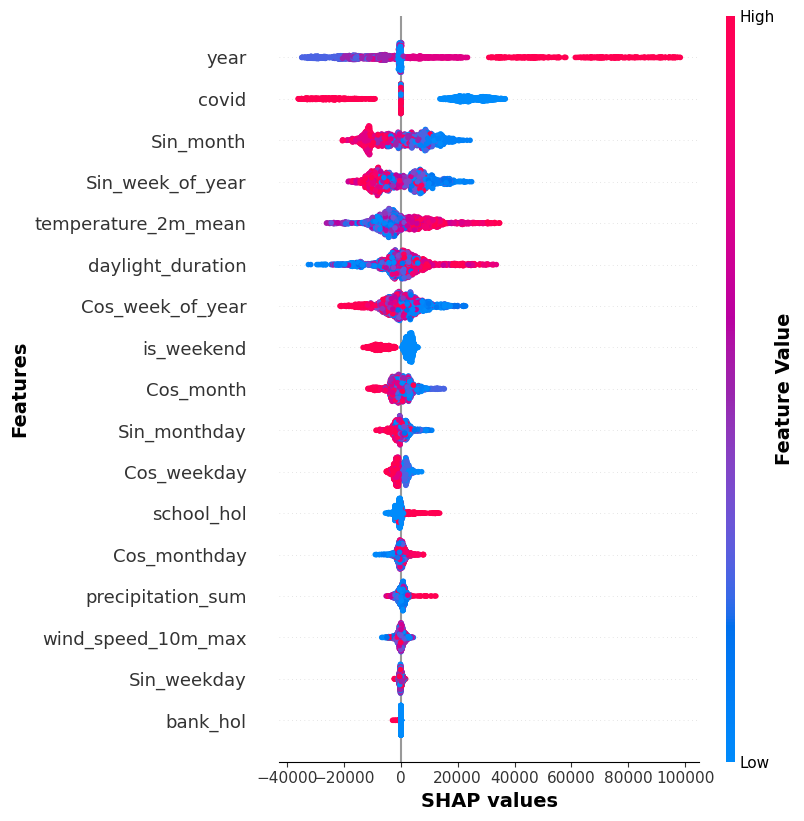

In [49]:
#Plot summary SHAP values
plt.figure(figsize=(40, 10))
shap.summary_plot(shap_df.values, 
                  Xfull.loc[shap_df.index], 
                  show = False)
plt.title('')
plt.xlabel('SHAP values', fontsize=14, weight='bold')
plt.ylabel('Features', fontsize=14, weight='bold')
cbar = plt.gcf().axes[-1] 
cbar.set_ylabel('Feature Value', fontsize=14, weight='bold')

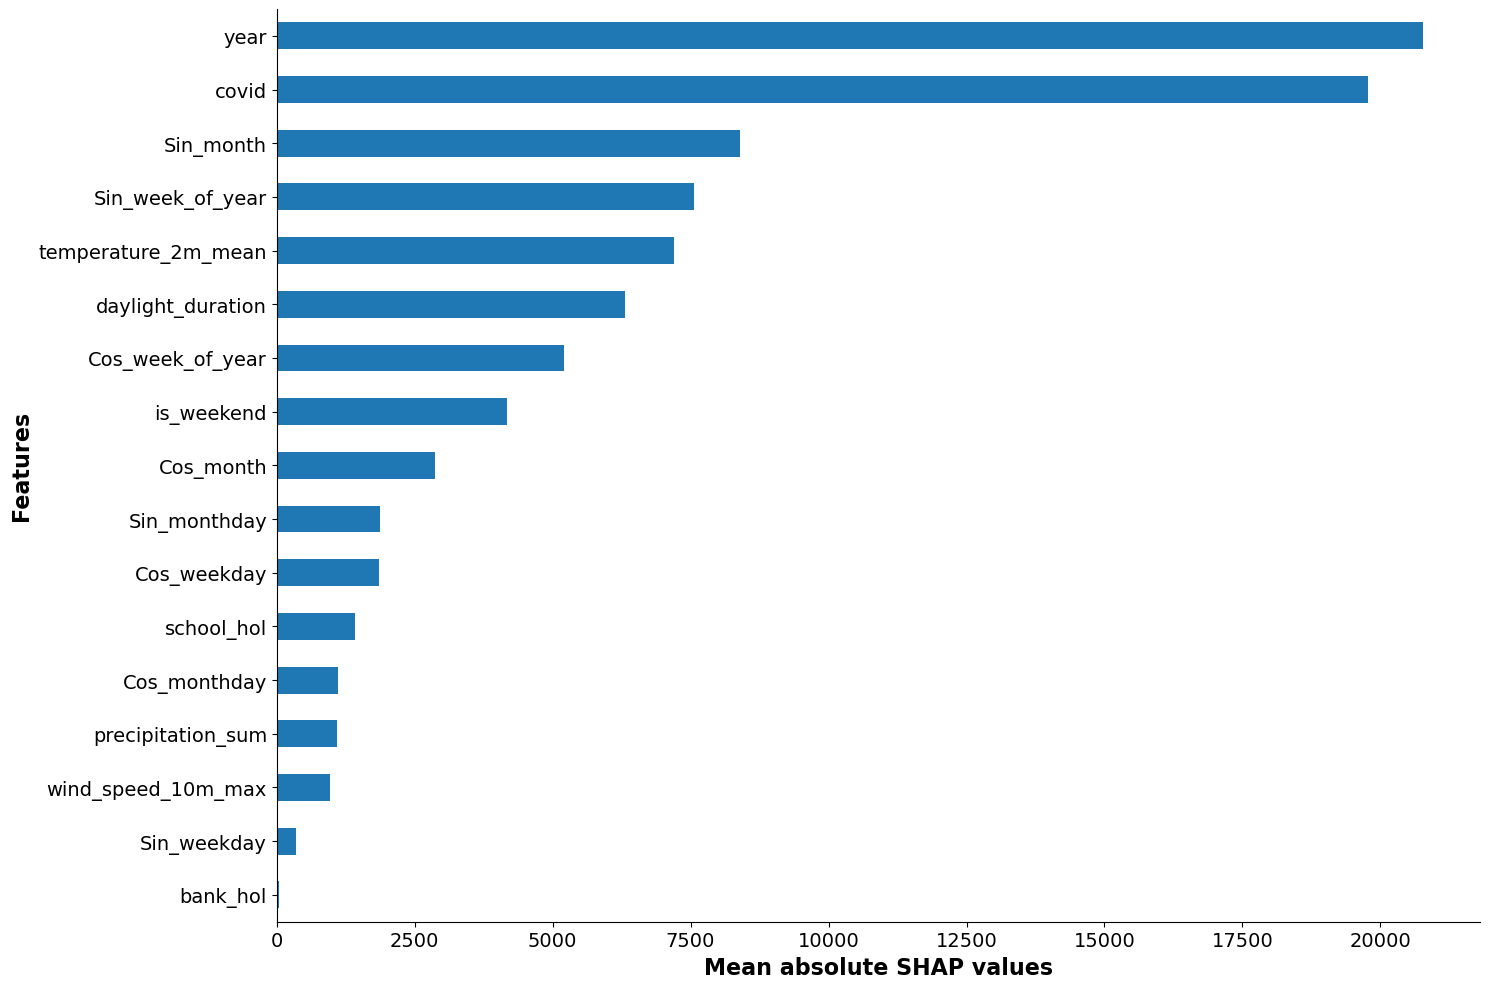

In [50]:
#Plot Mean Absolute SHAP values for each feature
mean_abs_shap = shap_df.abs().mean().sort_values()

#Plot
plt.figure(figsize=(15, 10))
mean_abs_shap.plot(kind='barh')
plt.title('')
plt.xlabel('Mean absolute SHAP values', fontsize=16, weight='bold')
plt.ylabel('Features', fontsize=16, weight='bold')
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [51]:
#Get the absolute mean SHAP values
mean_abs_shap

bank_hol                  45.903055
Sin_weekday              356.180057
wind_speed_10m_max       963.787239
precipitation_sum       1094.331458
Cos_monthday            1107.936579
school_hol              1425.706818
Cos_weekday             1844.702641
Sin_monthday            1868.605466
Cos_month               2876.520586
is_weekend              4166.706502
Cos_week_of_year        5205.774952
daylight_duration       6301.887900
temperature_2m_mean     7201.589687
Sin_week_of_year        7553.344905
Sin_month               8392.174582
covid                  19778.739083
year                   20767.627211
dtype: float64

# 6- Using RFR model to evaluate events

Now that the final Random Forest Regression has been trained on the footfall data between 2019 and 2024, the model is used to predict what footfall should have looked like in 2025 without any events, thus without the Bradford 2025 City of Culture program. Comparing the predicted vs the actual footfall values allows to access the success of the program by using footfall as a proxy.

In [52]:
#Load historical footfall (2019-2024) data again
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - Bradford District MetOffice\Bradford Analysis- RFR No lag-roll\footfall_cleaned_19_24")
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year', 'estimated_actual_footfall_rolling'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   datestamp                  2188 non-null   object 
 1   estimated_actual_footfall  2188 non-null   float64
 2   year                       2188 non-null   int64  
 3   Sin_weekday                2188 non-null   float64
 4   Cos_weekday                2188 non-null   float64
 5   Sin_monthday               2188 non-null   float64
 6   Cos_monthday               2188 non-null   float64
 7   Sin_week_of_year           2188 non-null   float64
 8   Cos_week_of_year           2188 non-null   float64
 9   Sin_month                  2188 non-null   float64
 10  Cos_month                  2188 non-null   float64
 11  is_weekend                 2188 non-null   int64  
 12  bank_hol                   2188 non-null   int64  
 13  school_hol                 2188 non-null   int64

In [53]:
#Get data to make prediction on -> the 2025 footfall data
#Load training footfall (2019-2024) data
data_2025 = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - Bradford District MetOffice\Bradford Analysis- RFR No lag-roll\footfall_cleaned_2025")
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         278 non-null    int64  
 1   datestamp                          278 non-null    object 
 2   estimated_actual_footfall          114 non-null    float64
 3   estimated_actual_footfall_rolling  278 non-null    int64  
 4   year                               278 non-null    int64  
 5   month                              278 non-null    int64  
 6   monthday                           278 non-null    int64  
 7   weekday                            278 non-null    int64  
 8   week_of_year                       278 non-null    int64  
 9   Sin_weekday                        278 non-null    float64
 10  Cos_weekday                        278 non-null    float64
 11  Sin_monthday                       278 non-null    float64

In [54]:
#Drop columns that are not variables used in the analysis
data_2025.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year', 'estimated_actual_footfall_rolling'], axis=1, inplace=True)

#Drop rows with no estimated_actual_footfall (won't allow comparison with predicted values)
data_2025 = data_2025.dropna(subset=['estimated_actual_footfall'])

data_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114 entries, 0 to 171
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   datestamp                  114 non-null    object 
 1   estimated_actual_footfall  114 non-null    float64
 2   year                       114 non-null    int64  
 3   Sin_weekday                114 non-null    float64
 4   Cos_weekday                114 non-null    float64
 5   Sin_monthday               114 non-null    float64
 6   Cos_monthday               114 non-null    float64
 7   Sin_week_of_year           114 non-null    float64
 8   Cos_week_of_year           114 non-null    float64
 9   Sin_month                  114 non-null    float64
 10  Cos_month                  114 non-null    float64
 11  is_weekend                 114 non-null    int64  
 12  bank_hol                   114 non-null    int64  
 13  school_hol                 114 non-null    int64  
 14 

In [55]:
#Prepare data for modelling
Xfull, Yfull = prepare_x_y_data(data_2025)

In [56]:
#Recursive forecasting function

"""
Recursive forecasting for future footfall

model: is the previously trained Random Forest Regressor model
history_df: is the data with historical data, used to previously train the model
future_df: is the data we want to predict the footfall for
            but excluding the rolling footfall
            including the 'datestamp' and 'estimated_actual_footfall' for comparison with model predictions
feature_cols: list of features used to train the model (excludes datestamp)

"""

def recursive_forecast(model, history_df, future_df, feature_cols):

    #Store footfall predictions
    predictions = []

    history = history_df.copy() #contains real past data + will contain predictions as loop runs

    for idx, row in future_df.iterrows():
        date = row['datestamp']
        row_copy = row.copy()

        # Select only the features in the row used for modelling
        X_row = row_copy[feature_cols].to_frame().T

        #Use model to predict footfall
        y_pred = rf_model_final.predict(X_row.values)[0]
        predictions.append(y_pred)

    #Add model predictions to the original future dataset
    future_df = future_df.copy()
    future_df['predicted_footfall'] = predictions
    return future_df

In [57]:
#Define the list of features used in model training
features = ['year', 
            'Sin_weekday',
            'Cos_weekday', 
            'Sin_week_of_year', 
            'Cos_week_of_year',
            'Sin_monthday',
            'Cos_monthday',
            'Sin_month',
            'Cos_month', 
            'is_weekend', 
            'bank_hol',
            'school_hol', 
            'covid', 
            'temperature_2m_mean',
            'precipitation_sum', 
            'wind_speed_10m_max', 
            'daylight_duration']

In [58]:
#Ensure the datestamp columns of both datasets are datetime
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
data['datestamp'] = pd.to_datetime(data['datestamp'])

In [59]:
#Call the recursive forecasting function
predictions_2025 = recursive_forecast(rf_model_final,
                                      data,
                                      data_2025,
                                      features)

predictions_2025.head()

,datestamp,estimated_actual_footfall,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,predicted_footfall
0,2025-01-01,577601.0,2025,8.660254e-01,-0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,1,1,0,5.187500,30.1,26.587042,27122.145,664391.506208
1,2025-01-02,607459.0,2025,1.224647e-16,-1.0,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,0,1,0,-0.789583,0.0,13.379461,27203.908,641752.194058
2,2025-01-03,599189.0,2025,-8.660254e-01,-0.5,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,0,0,1,0,1.508333,0.0,24.709875,27291.889,670041.547343
3,2025-01-04,624713.0,2025,-8.660254e-01,0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,1,0,0,0,0.641667,0.2,13.619471,27385.957,650150.590226
4,2025-01-05,553875.0,2025,-2.449294e-16,1.0,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,1,0,0,0,0.368750,31.6,21.240000,27485.986,647062.899375


Visualize prediction vs actual footfall values in 2025. To do so calculate the percentage increase between the two.

In [60]:
#Calculate the percentage increase
predictions_2025['Percentage_Increase'] = ((predictions_2025['estimated_actual_footfall'] - predictions_2025['predicted_footfall']) / abs(predictions_2025['predicted_footfall'])) * 100

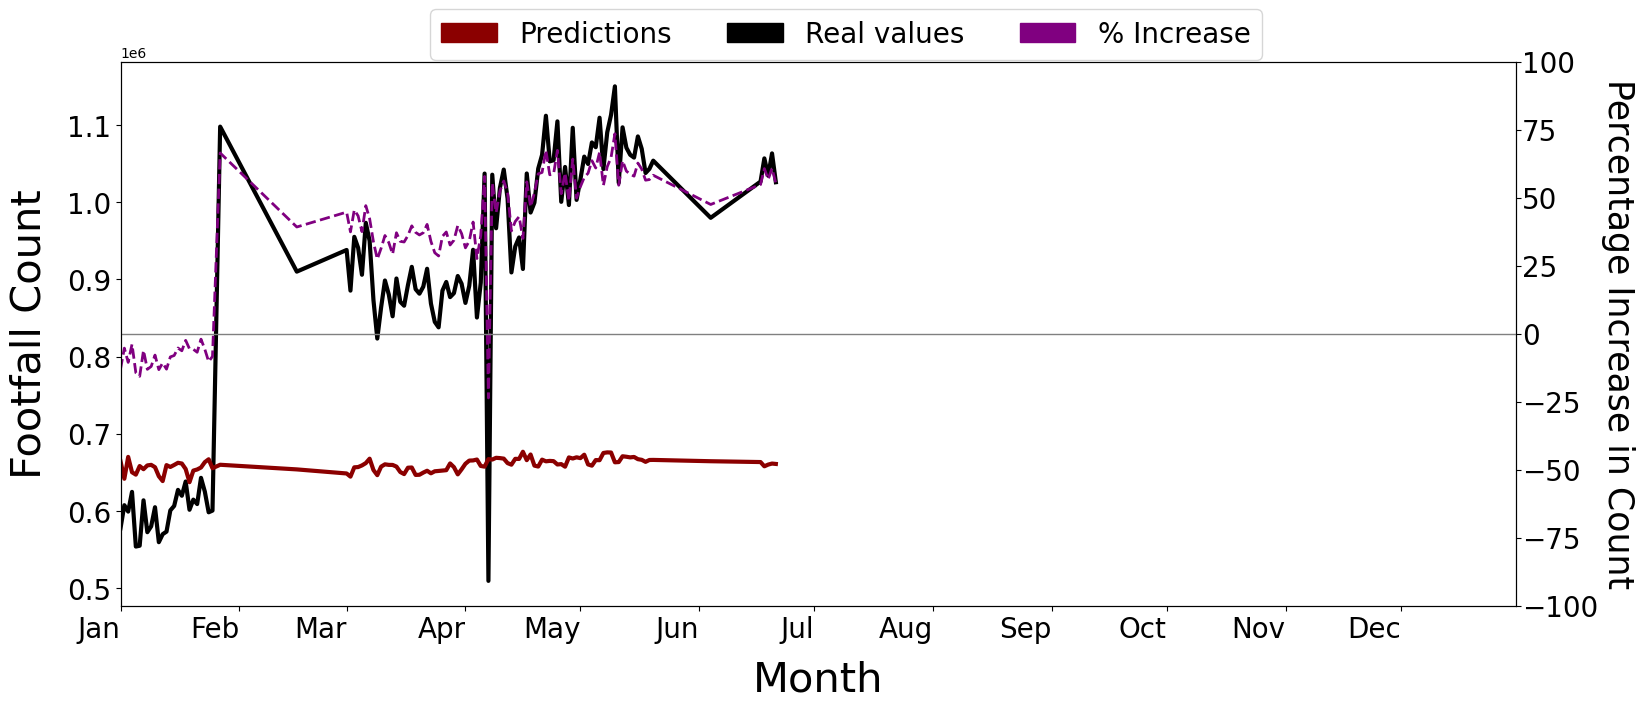

In [61]:
#Plot actual footfall, predicted footfall, and percentage increase between the two for comparison
import matplotlib.patches as mpatches
import matplotlib.dates as mdates


#Ensure datestamp is datetime
predictions_2025['datestamp'] = pd.to_datetime(predictions_2025['datestamp'])

include_percent_increase = True

fig, ax = plt.subplots(figsize = (18,8), sharex = True)

#Plot actual and predicted footfall
predictions_2025.plot(x='datestamp', y='estimated_actual_footfall', ax=ax, color='black', linewidth=3, legend =False)
predictions_2025.plot(x='datestamp', y='predicted_footfall', ax=ax, color='darkred', linewidth=3, legend =False)

#Plot percentage increase on secondary axis
if include_percent_increase==True:
    ax2 = ax.twinx()
    predictions_2025.plot(x='datestamp', y='Percentage_Increase', ax=ax2, color='purple', linewidth=2, legend =False, linestyle = 'dashed')
    ax2.set_ylabel('Percentage Increase in Count', fontsize=25, rotation=270, labelpad=27)
    ax2.tick_params(axis='both', which='major', labelsize=20, pad=1)
    ax2.set_ylim(-100,100)

#Set x axis to show month names, and tick parameters
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
#Force x axis to start in Jan and end in December
ax.set_xlim([pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31')])
ax.tick_params(axis='x', labelsize=20, rotation=0)
ax.tick_params(axis='y', labelsize=20)

#Set labels of axes
ax.set_xlabel('Month', fontsize = 30, labelpad=12)
ax.set_ylabel ('Footfall Count',fontsize=30, labelpad=12)

#Legend
colors_leg = ['darkred', 'black', 'purple']
texts = ['Predictions', 'Real values','% Increase'] 
patches = [ mpatches.Patch(color=colors_leg[i], label="{:s}".format(texts[i]) ) for i in range(len(texts)) ]    

plt.axhline(y = 0, color = 'grey', linestyle = '-', linewidth=1)     
plt.legend(handles=patches, bbox_to_anchor=(0.52, 1.05), loc='center', ncol=3, prop={'size': 20});

plt.show()

In [62]:
#Get yearly average of the %increase
predictions_2025.describe()

,datestamp,estimated_actual_footfall,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,...,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,predicted_footfall,Percentage_Increase
count,114,1.140000e+02,114.0,1.140000e+02,114.000000,114.000000,114.000000,114.000000,114.000000,1.140000e+02,...,114.000000,114.000000,114.000000,114.0,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,2025-03-24 08:50:31.578947328,8.912255e+05,2025.0,1.266044e-17,0.140351,0.061805,-0.121825,0.729168,0.034597,7.091823e-01,...,0.289474,0.035088,0.131579,0.0,7.987463,1.290351,16.380429,45011.347570,660008.910259,34.897965
min,2025-01-01 00:00:00,5.093770e+05,2025.0,-8.660254e-01,-1.000000,-0.998717,-0.994869,0.118273,-0.984231,1.224647e-16,...,0.000000,0.000000,0.000000,0.0,-4.066666,0.000000,5.081613,27122.145000,637259.832567,-23.654859
25%,2025-03-02 06:00:00,8.464572e+05,2025.0,-8.660254e-01,-0.500000,-0.651372,-0.758758,0.456629,-0.507884,5.000000e-01,...,0.000000,0.000000,0.000000,0.0,4.450000,0.000000,12.063357,39324.400000,655528.862018,28.709977
50%,2025-03-30 12:00:00,9.137295e+05,2025.0,0.000000e+00,0.500000,0.151233,-0.250653,0.875735,-0.029581,8.660254e-01,...,0.000000,0.000000,0.000000,0.0,8.013541,0.000000,16.214989,46619.228500,660155.696804,39.666775
75%,2025-04-27 18:00:00,1.041287e+06,2025.0,8.660254e-01,1.000000,0.724793,0.528964,0.964636,0.456051,1.000000e+00,...,1.000000,0.000000,0.000000,0.0,10.512500,0.500000,18.862455,53695.311750,666121.098100,56.577716
max,2025-06-21 00:00:00,1.150276e+06,2025.0,8.660254e-01,1.000000,0.998717,1.000000,0.999561,0.992981,1.000000e+00,...,1.000000,1.000000,1.000000,0.0,22.689583,31.600000,36.900440,61567.870000,676717.226555,73.483535
std,NaN,1.786693e+05,0.0,6.618558e-01,0.742242,0.708190,0.698920,0.297677,0.618578,2.728883e-01,...,0.455520,0.184814,0.339525,0.0,5.234448,4.499065,5.761902,10600.240212,8086.948965,26.364634


In [66]:
#Get the monthly %increase averages to see which month were most affected by the Bradford25 events
monthly_2025 = predictions_2025.groupby(predictions_2025['datestamp'].dt.month)['Percentage_Increase'].mean()
monthly_2025

datestamp
1    -5.706551
2    39.199031
3    36.408339
4    47.293893
5    60.220132
6    55.943561
Name: Percentage_Increase, dtype: float64